# 04 — PyTorch Dataset & DataLoader Preprocessing

 **Purpose:** Define TongueSegmentationDataset, configure augmentation,
 create DataLoaders, run a sanity check, and save a visual audit grid.

 **This notebook does NOT:** train a model or modify source folders.

In [11]:

import torch
import torchvision.transforms.functional as TF
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import random

print(f"torch   {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch   2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Ti


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2  Constants

In [13]:
OUTPUT_ROOT  = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")
SPLITS_DIR   = OUTPUT_ROOT / "03_splits"
AUDIT_DIR    = OUTPUT_ROOT / "04_visual_audits"

TRAIN_MANIFEST = SPLITS_DIR / "segmentation_train_manifest.csv"
VAL_MANIFEST   = SPLITS_DIR / "segmentation_val_manifest.csv"
TEST_MANIFEST  = SPLITS_DIR / "segmentation_test_manifest.csv"

IMG_SIZE    = 384
BATCH_SIZE  = 8
SEED        = 42
NUM_WORKERS = 0       # must be 0 on Windows to avoid multiprocessing spawn errors
PIN_MEMORY  = torch.cuda.is_available()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

for path in [TRAIN_MANIFEST, VAL_MANIFEST, TEST_MANIFEST]:
    assert path.exists(), (
        f"Split manifest not found: {path}\n"
        "Run Notebook 3 first."
    )

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
print("All manifests found.")
print(f"PIN_MEMORY = {PIN_MEMORY}")


All manifests found.
PIN_MEMORY = True


# 3  Reproducibility Seed

In [14]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Global seed set to {SEED}.")


Global seed set to 42.


# 4  Dataset Class

# Design decisions made explicit:
 - Augmentation is applied **jointly** to image and mask using manual TF calls
   (not torchvision transforms pipeline) so that spatial ops stay in sync.
 - Mask resizing uses **nearest-neighbor** only to preserve binary values.
 - Mask is converted to binary float32 {0.0, 1.0} — NOT {0, 255}.
 - Normalization is applied to the **image only**, never the mask.
 - No augmentation for val or test — deterministic preprocessing only.

In [15]:
class TongueSegmentationDataset(Dataset):
    """
    PyTorch Dataset for tongue segmentation.

    Returns per sample:
        image  : float32 tensor [3, IMG_SIZE, IMG_SIZE]  (ImageNet-normalized)
        mask   : float32 tensor [1, IMG_SIZE, IMG_SIZE]  (binary 0.0 / 1.0)
        meta   : dict with sample_id, patient_id, image_path, mask_path
    """

    def __init__(self, manifest_path: Path, img_size: int, augment: bool = False):
        """
        Args:
            manifest_path : path to a split CSV manifest
            img_size      : target square size (e.g. 384)
            augment       : True for train split only
        """
        self.df       = pd.read_csv(manifest_path)
        self.img_size = img_size
        self.augment  = augment

        # Validate required columns
        for col in ["sample_id", "patient_id", "image_path", "mask_path"]:
            assert col in self.df.columns, f"Missing required column: {col}"

        self.mean = IMAGENET_MEAN
        self.std  = IMAGENET_STD

    def __len__(self):
        return len(self.df)

    def _load_image(self, path: str) -> Image.Image:
        """Load image as RGB PIL."""
        img = Image.open(path).convert("RGB")
        return img

    def _load_mask(self, path: str) -> Image.Image:
        """Load mask as grayscale PIL."""
        mask = Image.open(path).convert("L")
        return mask

    def _resize_image(self, img: Image.Image) -> Image.Image:
        """Resize image with bilinear interpolation."""
        return TF.resize(img, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.BILINEAR)

    def _resize_mask(self, mask: Image.Image) -> Image.Image:
        """Resize mask with NEAREST to preserve binary values."""
        return TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.NEAREST)

    def _apply_augmentation(self, img: Image.Image, mask: Image.Image):
        """
        Training augmentations applied jointly to image and mask.
        Spatial ops: random horizontal flip, random rotation.
        Photometric ops: brightness/contrast jitter on image ONLY.
        """
        # Random horizontal flip
        if random.random() > 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        # Random rotation ±10 degrees
        angle = random.uniform(-10.0, 10.0)
        img   = TF.rotate(img,  angle, interpolation=TF.InterpolationMode.BILINEAR, fill=0)
        mask  = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST,  fill=0)

        # Brightness/contrast jitter — image ONLY
        brightness_factor = random.uniform(0.85, 1.15)
        contrast_factor   = random.uniform(0.85, 1.15)
        img = TF.adjust_brightness(img, brightness_factor)
        img = TF.adjust_contrast(img,  contrast_factor)

        return img, mask

    def _image_to_tensor(self, img: Image.Image) -> torch.Tensor:
        """Convert PIL RGB image to normalized float32 tensor [3, H, W]."""
        t = TF.to_tensor(img)                      # [3,H,W], float32, range [0,1]
        t = TF.normalize(t, self.mean, self.std)   # ImageNet normalization
        return t

    def _mask_to_tensor(self, mask: Image.Image) -> torch.Tensor:
        """
        Convert PIL grayscale mask to binary float32 tensor [1, H, W].
        Values are 0.0 (background) or 1.0 (tongue).
        """
        t = TF.to_tensor(mask)           # [1,H,W], float32, values in {0.0, 1.0} (PIL L mode)
        t = (t > 0.5).float()            # hard threshold: binarize to exactly 0.0 / 1.0
        return t

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        img  = self._load_image(row["image_path"])
        mask = self._load_mask(row["mask_path"])

        # Resize first, then augment (augment on smaller tensor is faster)
        img  = self._resize_image(img)
        mask = self._resize_mask(mask)

        if self.augment:
            img, mask = self._apply_augmentation(img, mask)

        img_tensor  = self._image_to_tensor(img)
        mask_tensor = self._mask_to_tensor(mask)

        meta = {
            "sample_id"  : str(row["sample_id"]),
            "patient_id" : str(row["patient_id"]),
            "image_path" : str(row["image_path"]),
            "mask_path"  : str(row["mask_path"]),
        }

        return img_tensor, mask_tensor, meta

# 5  Instantiate Datasets

In [16]:
train_dataset = TongueSegmentationDataset(TRAIN_MANIFEST, img_size=IMG_SIZE, augment=True)
val_dataset   = TongueSegmentationDataset(VAL_MANIFEST,   img_size=IMG_SIZE, augment=False)
test_dataset  = TongueSegmentationDataset(TEST_MANIFEST,  img_size=IMG_SIZE, augment=False)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train samples : 3671
Val   samples : 790
Test  samples : 804


# 6  Create DataLoaders

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 459
Val   batches : 99
Test  batches : 101


# 7  Single-Batch Sanity Check

In [18]:
set_seed(SEED)
images, masks, metas = next(iter(train_loader))

print("=" * 52)
print(f"  Image tensor shape   : {images.shape}")
print(f"  Mask  tensor shape   : {masks.shape}")
print(f"  Image dtype          : {images.dtype}")
print(f"  Mask  dtype          : {masks.dtype}")
print(f"  Image min / max      : {images.min():.4f} / {images.max():.4f}")
print(f"  Mask  unique values  : {torch.unique(masks).tolist()}")
print(f"  Mask  value range    : {masks.min():.1f} / {masks.max():.1f}")
print("=" * 52)

# Assertions
assert images.shape == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), (
    f"Unexpected image shape: {images.shape}"
)
assert masks.shape == (BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE), (
    f"Unexpected mask shape: {masks.shape}"
)
assert images.dtype == torch.float32, "Image tensor is not float32."
assert masks.dtype  == torch.float32, "Mask tensor is not float32."
assert set(torch.unique(masks).tolist()).issubset({0.0, 1.0}), (
    f"Mask contains non-binary values: {torch.unique(masks).tolist()}"
)
print("All sanity check assertions passed.")

  Image tensor shape   : torch.Size([8, 3, 384, 384])
  Mask  tensor shape   : torch.Size([8, 1, 384, 384])
  Image dtype          : torch.float32
  Mask  dtype          : torch.float32
  Image min / max      : -2.1179 / 2.6400
  Mask  unique values  : [0.0, 1.0]
  Mask  value range    : 0.0 / 1.0
All sanity check assertions passed.


# 8  Visual Audit Grid
 Shows denormalized image | binary mask | red overlay for one full batch.
 Saved to `04_visual_audits/04_dataloader_sanity_check.png`.

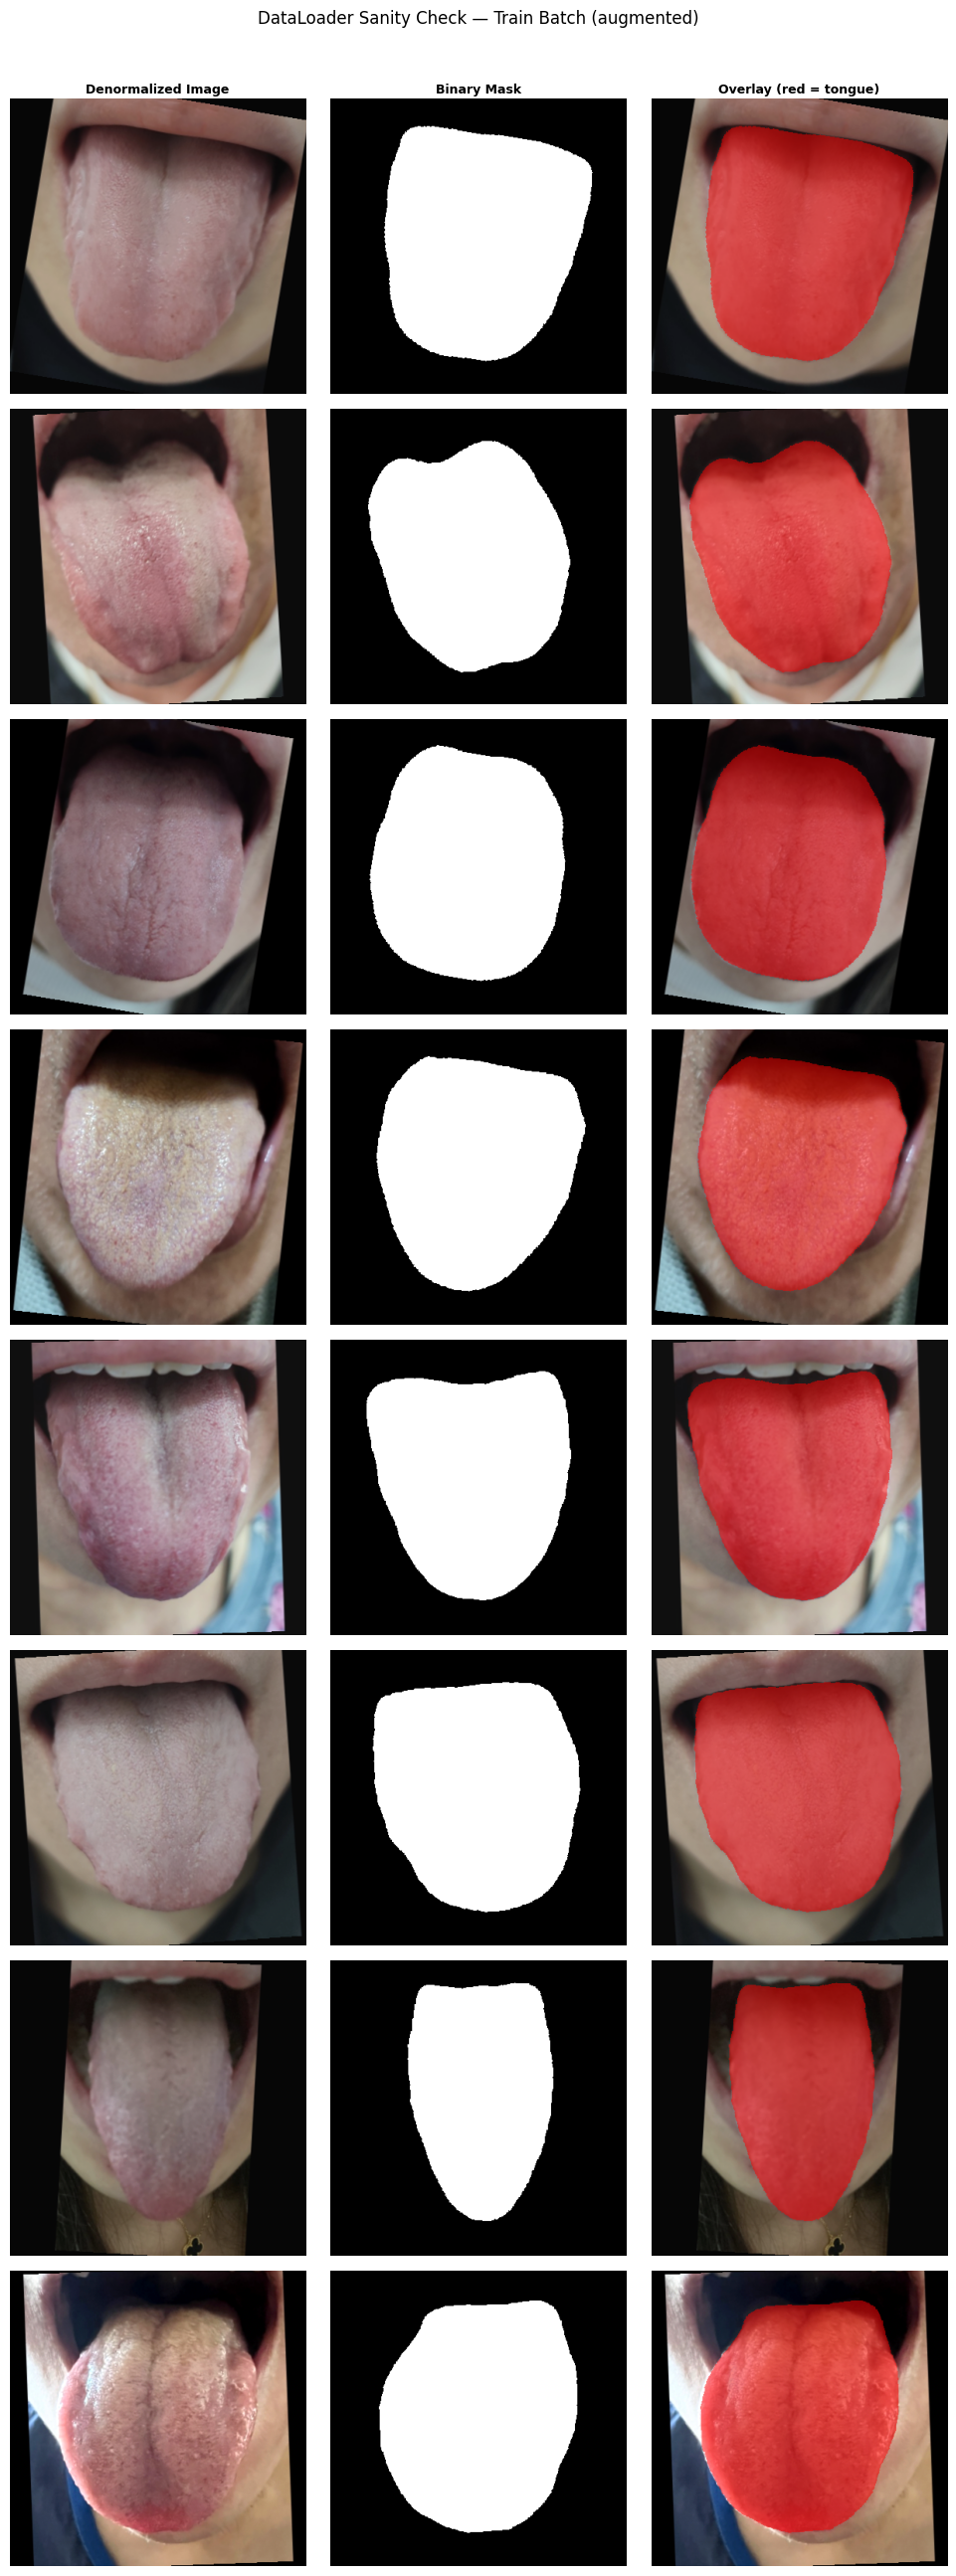

Visual audit saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\04_dataloader_sanity_check.png


In [19]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse ImageNet normalization and return uint8 HxWx3 numpy array.
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    t    = tensor.clone().cpu() * std + mean
    t    = t.clamp(0.0, 1.0)
    return (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def mask_to_rgb(mask_tensor: torch.Tensor) -> np.ndarray:
    """Return grayscale mask as uint8 HxW array."""
    return (mask_tensor.squeeze(0).cpu().numpy() * 255).astype(np.uint8)


def make_overlay(img_arr: np.ndarray, mask_arr: np.ndarray) -> np.ndarray:
    """Blend red tongue region over original image."""
    overlay = img_arr.copy().astype(np.float32)
    tongue  = (mask_arr == 255)
    overlay[tongue, 0] = np.clip(overlay[tongue, 0] * 0.5 + 127, 0, 255)
    overlay[tongue, 1] = np.clip(overlay[tongue, 1] * 0.5,       0, 255)
    overlay[tongue, 2] = np.clip(overlay[tongue, 2] * 0.5,       0, 255)
    return overlay.astype(np.uint8)


AUDIT_SAVE_PATH = AUDIT_DIR / "04_dataloader_sanity_check.png"

n_show  = min(BATCH_SIZE, len(images))
n_cols  = 3
fig, axes = plt.subplots(n_show, n_cols, figsize=(10, n_show * 3.2),
                          squeeze=False)

col_headers = ["Denormalized Image", "Binary Mask", "Overlay (red = tongue)"]
for c, hdr in enumerate(col_headers):
    axes[0, c].set_title(hdr, fontsize=9, fontweight="bold", pad=4)

for i in range(n_show):
    img_arr  = denormalize(images[i])
    mask_arr = mask_to_rgb(masks[i])
    ov_arr   = make_overlay(img_arr, mask_arr)

    axes[i, 0].imshow(img_arr)
    axes[i, 0].set_ylabel(metas["sample_id"][i], fontsize=6,
                           rotation=0, labelpad=55, va="center")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_arr, cmap="gray", vmin=0, vmax=255)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(ov_arr)
    axes[i, 2].axis("off")

fig.suptitle(f"DataLoader Sanity Check — Train Batch (augmented)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(AUDIT_SAVE_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Visual audit saved -> {AUDIT_SAVE_PATH}")

# Notebook Complete

 | Component | Detail |
 |-----------|--------|
 | Dataset class | `TongueSegmentationDataset` |
 | Image output  | float32 [3, 384, 384], ImageNet-normalized |
 | Mask output   | float32 [1, 384, 384], binary {0.0, 1.0} |
 | Train aug     | H-flip, ±10° rotation, brightness/contrast jitter |
 | Val/Test aug  | None |
 | num_workers   | 0 (Windows-safe) |
 | Visual audit  | `04_visual_audits/04_dataloader_sanity_check.png` |

 **Model is not trained here.**
 **Next step:** run `05_model_definition_efficientnetb0_unet.ipynb`.